In [1]:
import torch
import numpy as np
import normflows as nf

import pid.utils.distributions
from pid.utils.distributions import DiagGaussian

from matplotlib import pyplot as plt

from tqdm import tqdm

In [2]:
# Define 2D Gaussian base distribution
base = pid.utils.distributions.GaussianPCA(dim=2, latent_dim=2, sigma=0.1)
# base = DiagGaussian(2, trainable=False)

# Define list of flows
num_layers = 32
flows = []
for i in range(num_layers):
    # Neural network with two hidden layers having 64 units each
    # Last layer is initialized by zeros making training more stable
    param_map = nf.nets.MLP([1, 64, 64, 2], init_zeros=True)
    # Add flow layer
    flows.append(nf.flows.AffineCouplingBlock(param_map))
    # Swap dimensions
    flows.append(nf.flows.Permute(2, mode='swap'))

# Construct flow model
model = nf.NormalizingFlow(base, flows)

In [3]:
# Move model on GPU if available
enable_cuda = True
device = torch.device('cuda' if torch.cuda.is_available() and enable_cuda else 'cpu')
model = model.to(device)
print(f"Using device: {device}")

Using device: cuda


In [4]:
# Define target distribution
target = nf.distributions.TwoMoons()

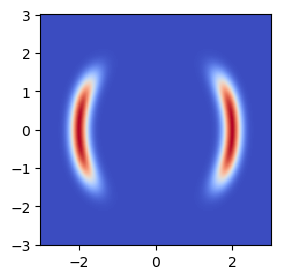

In [5]:
# Plot target distribution
grid_size = 200
xx, yy = torch.meshgrid(torch.linspace(-3, 3, grid_size), torch.linspace(-3, 3, grid_size), indexing='ij')
zz = torch.cat([xx.unsqueeze(2), yy.unsqueeze(2)], 2).view(-1, 2)
zz = zz.to(device)

log_prob = target.log_prob(zz).to('cpu').view(*xx.shape)
prob = torch.exp(log_prob)
prob[torch.isnan(prob)] = 0

plt.figure(figsize=(3, 3))
plt.pcolormesh(xx, yy, prob.data.numpy(), cmap='coolwarm')
plt.gca().set_aspect('equal', 'box')
plt.show()

In [6]:
# Train model
max_iter = 4000
num_samples = 2 ** 9
show_iter = 500

loss_hist = np.array([])

optimizer = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-5)

for it in tqdm(range(max_iter)):
    optimizer.zero_grad()

    # Get training samples
    x = target.sample(num_samples).to(device)

    # Compute loss
    loss = model.forward_kld(x)

    # Do backprop and optimizer step
    if ~(torch.isnan(loss) | torch.isinf(loss)):
        loss.backward()
        optimizer.step()

    # Log loss
    loss_hist = np.append(loss_hist, loss.to('cpu').data.numpy())

100%|██████████| 4000/4000 [01:58<00:00, 33.79it/s]


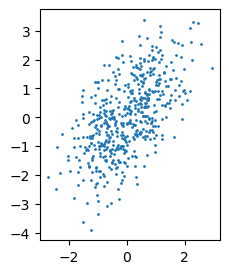

In [7]:
# Sample from latent distribution
model.eval()
x = target.sample(num_samples).to(device)
z, _ = model.inverse_and_log_det(x)
z = z.to('cpu').data.numpy()
plt.figure(figsize=(4, 3))
plt.scatter(z[:, 0], z[:, 1], s=1)
plt.gca().set_aspect('equal', 'box')
plt.show()

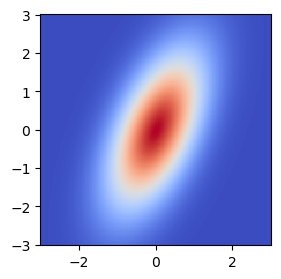

In [8]:
# Plot the latent distribution
model.eval()
log_prob = model.q0.log_prob(zz)
prob = torch.exp(log_prob.to('cpu').view(*xx.shape))
prob[torch.isnan(prob)] = 0

# x = target.sample(num_samples).to(device)
# z, _ = model.inverse_and_log_det(x)
# z = z.to('cpu').data.numpy()
# plt.figure(figsize=(5, 5))
# plt.scatter(z[:, 0], z[:, 1], s=1)
# plt.gca().set_aspect('equal', 'box')

plt.figure(figsize=(4, 3))
plt.pcolormesh(xx, yy, prob.data.numpy(), cmap='coolwarm')
plt.gca().set_aspect('equal', 'box')
plt.show()

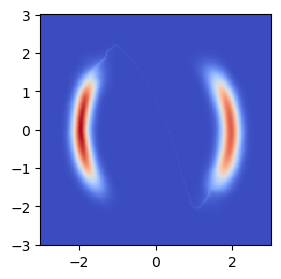

In [9]:
# Plot learned distribution
model.eval()
log_prob = model.log_prob(zz)
prob = torch.exp(log_prob.to('cpu').view(*xx.shape))
prob[torch.isnan(prob)] = 0

plt.figure(figsize=(3, 3))
plt.pcolormesh(xx, yy, prob.data.numpy(), cmap='coolwarm')
plt.gca().set_aspect('equal', 'box')
plt.show()

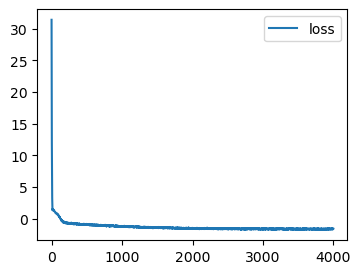

In [10]:
# Plot loss
plt.figure(figsize=(4, 3))
plt.plot(loss_hist, label='loss')
plt.legend()
plt.show()